**Fraud Detection EDA Notebook**

This notebook performs exploratory data analysis (EDA) on the (/content/drive/MyDrive/Colab Notebooks/fraudTest.csv) dataset. It covers data overview, summary statistics, missing values, target distribution, numerical and categorical feature analysis, and basic visualizations. Feel free to run the cells step by step and modify them for deeper insights.




In [165]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [250]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

# import warnings
import warnings
warnings.filterwarnings('ignore')


In [167]:
data= pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/fraudTest.csv")

In [168]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [169]:
print(f"Dataset contains {data.shape[0]} rows and {data.shape[1]} columns.")

Dataset contains 555719 rows and 23 columns.


In [170]:
data.columns.to_list()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [171]:
# data overview
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [172]:
pd.DataFrame({"Missing_Values": data.isnull().sum(),
              "DataType": data.dtypes})

,Missing_Values,DataType
Unnamed: 0,0,int64
trans_date_trans_time,0,object
cc_num,0,int64
merchant,0,object
category,0,object
amt,0,float64
first,0,object
last,0,object
gender,0,object
street,0,object


In [173]:
# dropping the columns

df= data.drop(columns=['Unnamed: 0', 'cc_num', 'street','zip','lat', 'long', 'city_pop','trans_num', 'unix_time','merch_lat', 'merch_long'],axis=1)

In [174]:
df.head()

,trans_date_trans_time,merchant,category,amt,first,last,gender,city,state,job,dob,is_fraud
0,2020-06-21 12:14:25,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,Columbia,SC,Mechanical engineer,1968-03-19,0
1,2020-06-21 12:14:33,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,Altonah,UT,"Sales professional, IT",1990-01-17,0
2,2020-06-21 12:14:53,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,Bellmore,NY,"Librarian, public",1970-10-21,0
3,2020-06-21 12:15:15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,Titusville,FL,Set designer,1987-07-25,0
4,2020-06-21 12:15:17,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,Falmouth,MI,Furniture designer,1955-07-06,0


In [175]:
 df.describe()

,amt,is_fraud
count,555719.000000,555719.000000
mean,69.392810,0.003860
std,156.745941,0.062008
min,1.000000,0.000000
25%,9.630000,0.000000
50%,47.290000,0.000000
75%,83.010000,0.000000
max,22768.110000,1.000000


is_fraud
Non-Fraud    553574
Fraud          2145
Name: count, dtype: int64


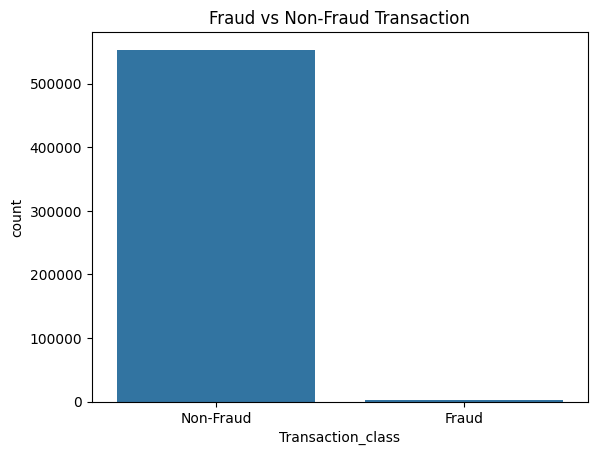

In [176]:
# target column
class_counts= df['is_fraud'].value_counts().rename(index={0:'Non-Fraud', 1: 'Fraud'})
print(class_counts)

plt.figure()
sns.barplot(x=class_counts.index, y= class_counts.values)
plt.title('Fraud vs Non-Fraud Transaction')
plt.xlabel('Transaction_class')
plt.ylabel('count')
plt.show()

category
shopping_net     506
grocery_pos      485
misc_net         267
shopping_pos     213
gas_transport    154
misc_pos          72
personal_care     70
home              67
kids_pets         65
entertainment     59
Name: count, dtype: int64


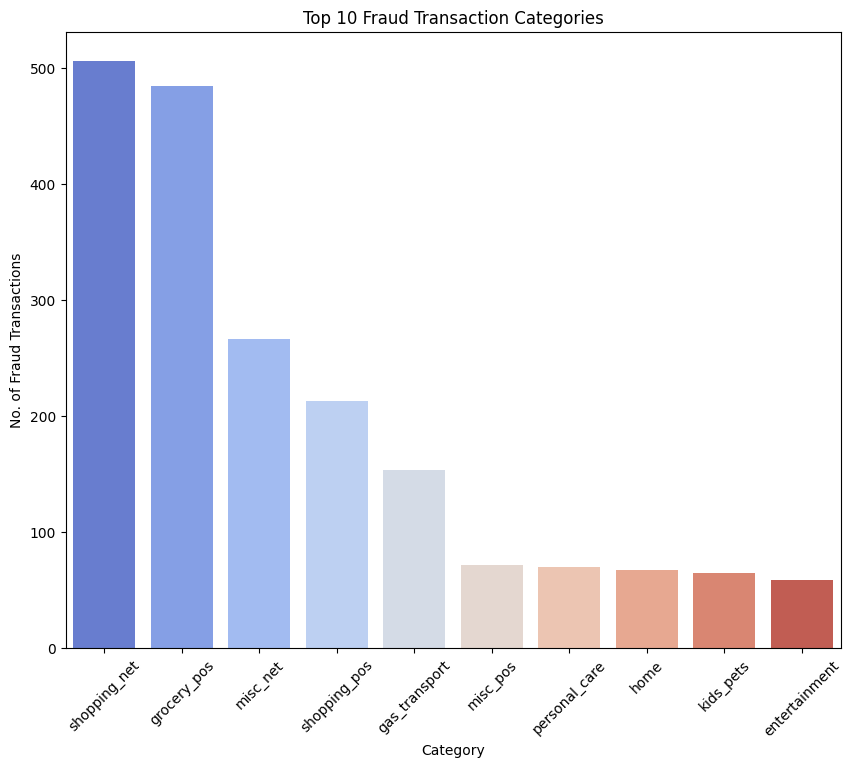

In [177]:
# Distribution of target column

category_counts = df[df['is_fraud'] == 1]['category'].value_counts().head(10)
print(category_counts)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette='coolwarm')
plt.xticks(rotation=45)
plt.xlabel('Category')
plt.ylabel('No. of Fraud Transactions')
plt.title('Top 10 Fraud Transaction Categories')
plt.show()

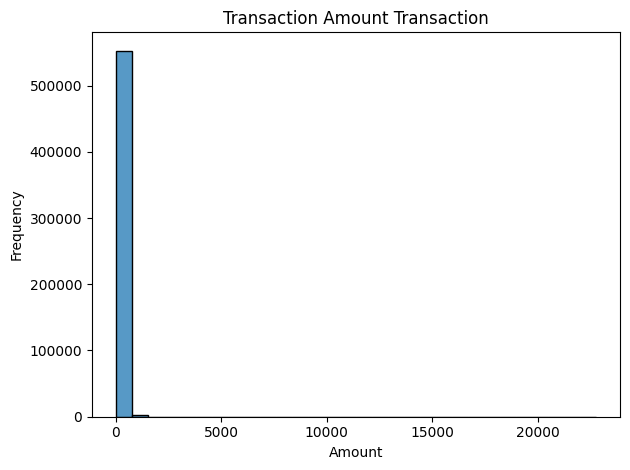

In [178]:
# histogram of transaction amount

plt.figure()
sns.histplot(x='amt', data=df, bins=30)
plt.title('Transaction Amount Transaction')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Axes: xlabel='amt'>

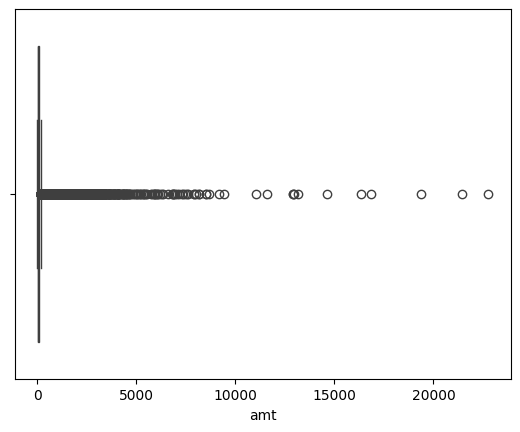

In [179]:
sns.boxplot(x=df['amt'])

In [180]:
numeric_cols= df.select_dtypes(include=['number']).columns
numeric_cols

Index(['amt', 'is_fraud'], dtype='object')

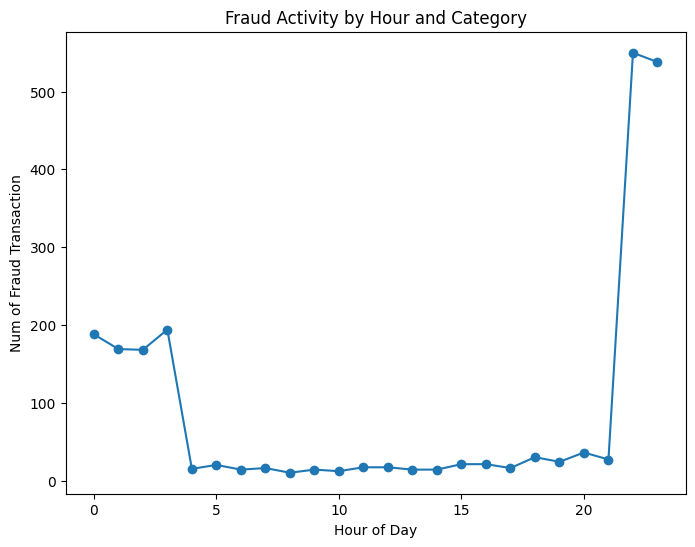

In [181]:
df['trans_date_trans_time']= pd.to_datetime(df['trans_date_trans_time'])
df['hour']= df['trans_date_trans_time'].dt.hour
fraud_hour= df.groupby('hour')['is_fraud'].sum()


plt.figure(figsize=(8,6))
fraud_hour.plot(kind='line', marker='o')
plt.title('Fraud Activity by Hour and Category')
plt.xlabel('Hour of Day')
plt.ylabel('Num of Fraud Transaction')
plt.show()

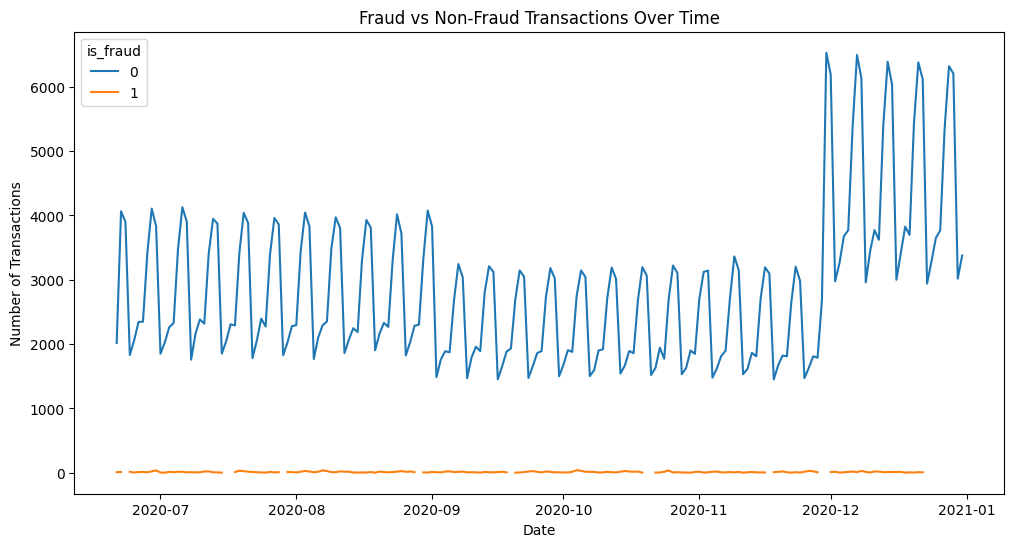

In [182]:
daily_transactions = df.groupby(df['trans_date_trans_time'].dt.date)['is_fraud'].value_counts().unstack()

daily_transactions.plot(figsize=(12,6))
plt.title('Fraud vs Non-Fraud Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.show()

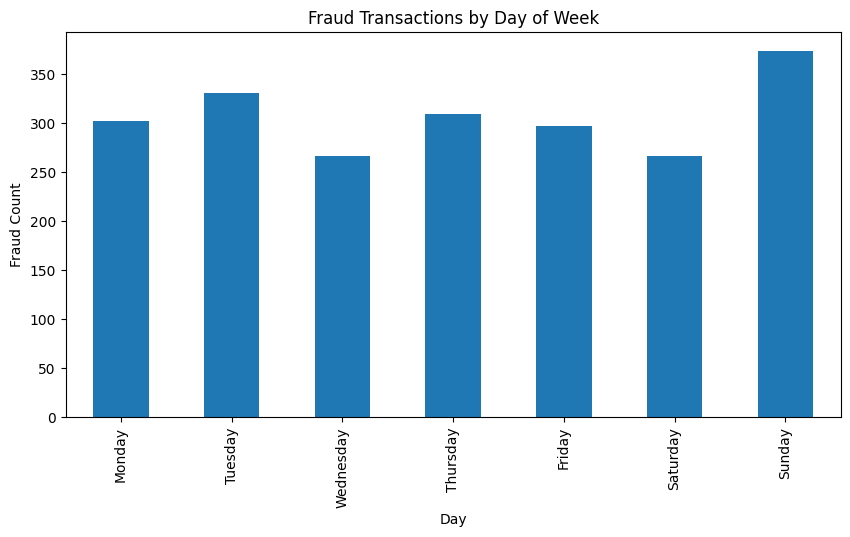

In [183]:
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()

fraud_day = df.groupby('day_of_week')['is_fraud'].sum()

fraud_day = fraud_day.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,5))
fraud_day.plot(kind='bar')
plt.title('Fraud Transactions by Day of Week')
plt.xlabel('Day')
plt.ylabel('Fraud Count')
plt.show()

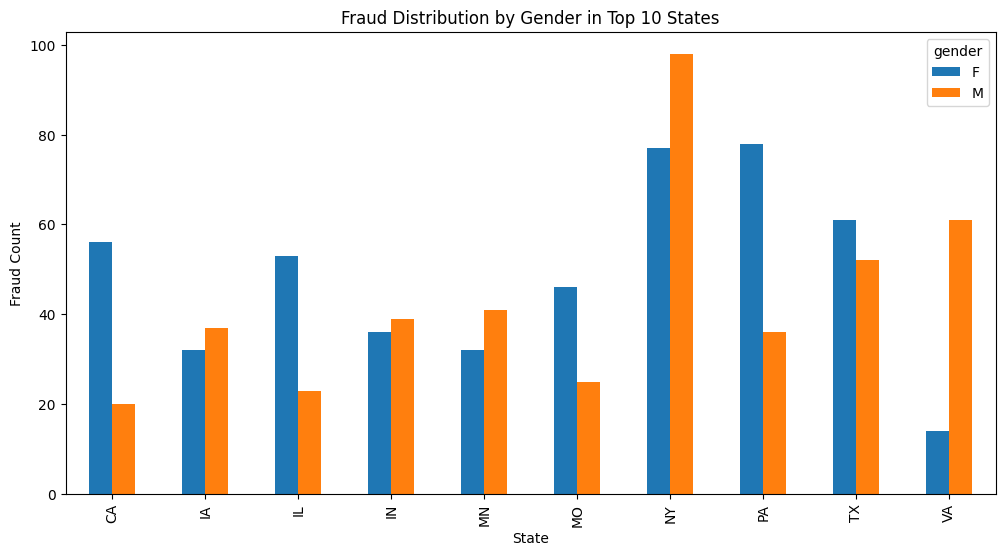

In [184]:
top10_states = df[df['is_fraud']==1]['state'].value_counts().head(10).index

fraud_gender_state = df[(df['state'].isin(top10_states)) & (df['is_fraud']==1)]

pivot = pd.pivot_table(
        fraud_gender_state,
        values='is_fraud',
        index='state',
        columns='gender',
        aggfunc='count'
)

pivot.plot(kind='bar', figsize=(12,6))

plt.title("Fraud Distribution by Gender in Top 10 States")
plt.xlabel("State")
plt.ylabel("Fraud Count")
plt.show()

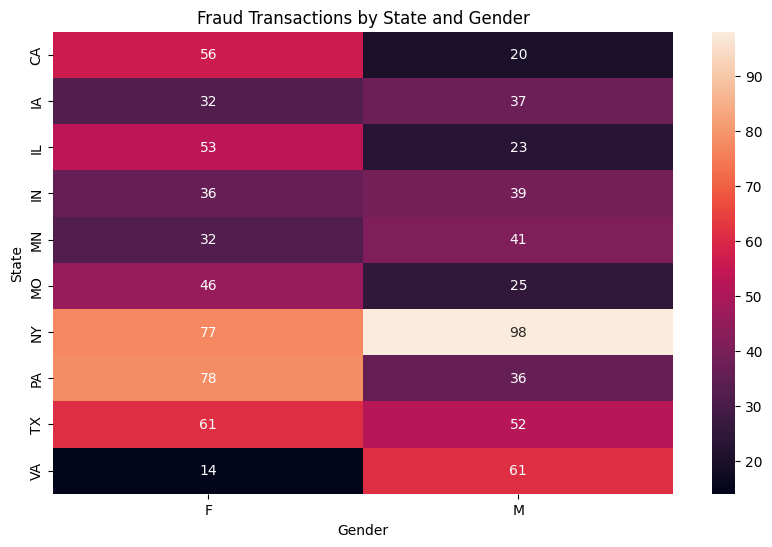

In [185]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt='g')

plt.title("Fraud Transactions by State and Gender")
plt.xlabel("Gender")
plt.ylabel("State")
plt.show()

In [186]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'city', 'state', 'job', 'dob', 'is_fraud', 'hour',
       'day_of_week'],
      dtype='object')

In [187]:
df['dob']= pd.to_datetime(df['dob']).dt.year
df['age']= df['trans_date_trans_time'].dt.year - df['dob']

In [188]:
df['year'] = pd.to_datetime(df['trans_date_trans_time']).dt.year
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df['month'] = pd.to_datetime(df['trans_date_trans_time']).dt.month

In [189]:
df1= df.drop(columns=['dob','trans_date_trans_time','first','last'])

In [197]:
merchant_fraud_rate = df1.groupby('merchant')['is_fraud'].mean()

df1['merchant_risk'] = df1['merchant'].map(merchant_fraud_rate)*100

In [191]:
cat_cols= df1.select_dtypes(include='O')


In [200]:
# encoding

le= LabelEncoder()
for col in cat_cols:
  df1[col] = le.fit_transform(df1[col])

In [204]:
df1.head()

,merchant,category,amt,gender,city,state,job,is_fraud,hour,day_of_week,age,year,month,merchant_risk
0,319,10,2.86,1,157,39,275,0,12,3,52,2020,6,0.407609
1,591,10,29.84,0,16,43,392,0,12,3,30,2020,6,0.127389
2,611,5,41.28,0,61,33,259,0,12,3,50,2020,6,0.132450
3,222,9,60.05,1,764,8,407,0,12,3,33,2020,6,0.421941
4,292,13,3.19,1,247,21,196,0,12,3,65,2020,6,0.270270


In [208]:
# dependency split

x= df1.drop('is_fraud', axis=1)
y= df['is_fraud']

# train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [220]:
print(f"x_train_shape:",x_train.shape)
print(f"x_test_shape:",x_test.shape)
print(f"y_train_shape:",y_train.shape)
print(f"y_test_shape:",y_test.shape)

x_train_shape: (444575, 13)
x_test_shape: (111144, 13)
y_train_shape: (444575,)
y_test_shape: (111144,)


In [251]:
# scaling

scaler= StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit(x_test)


In [230]:
smote= SMOTE(random_state=42)

x_train_sm, y_train_sm = smote.fit_resample(x_train_scaled,y_train)

In [242]:
# build ann

model= Sequential()

model.add(Dense(units=64,
                kernel_initializer='he_uniform',
                input_dim= x_train_sm.shape[1]))

# first hidden layer
model.add(Dense(units=32, kernel_initializer='he_uniform',
                activation='relu'))
# second hidden layer
model.add(Dense(units=16, kernel_initializer='he_uniform',
                activation='relu'))
# output layer
model.add(Dense(units=1, activation='sigmoid'))

# back propagation
model.compile(optimizer='SGD',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [243]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [248]:
hist= model.fit(
    x_train_sm, y_train_sm,
    validation_split=0.2,
    batch_size=256,
    epochs=10
)

Epoch 1/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9608 - loss: 0.1027 - val_accuracy: 0.9433 - val_loss: 0.1386
Epoch 2/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9617 - loss: 0.1003 - val_accuracy: 0.9483 - val_loss: 0.1362
Epoch 3/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9622 - loss: 0.0990 - val_accuracy: 0.9505 - val_loss: 0.1265
Epoch 4/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9635 - loss: 0.0963 - val_accuracy: 0.9487 - val_loss: 0.1274
Epoch 5/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9642 - loss: 0.0946 - val_accuracy: 0.9553 - val_loss: 0.1159
Epoch 6/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9648 - loss: 0.0934 - val_accuracy: 0.9552 - val_loss: 0.1190
Epoch 7/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9657 - loss: 0.0918 - val_accuracy: 0.9546 - val_loss: 0.1169
Epoch 8/10
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9665 - loss: 0.089

In [253]:
x_test_scaled = scaler.transform(x_test)
y_pred_prob = model.predict(x_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
[[107978   2740]
 [    50    376]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    110718
           1       0.12      0.88      0.21       426

    accuracy                           0.97    111144
   macro avg       0.56      0.93      0.60    111144
weighted avg       1.00      0.97      0.98    111144

ROC-AUC Score: 0.9798094885055438


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


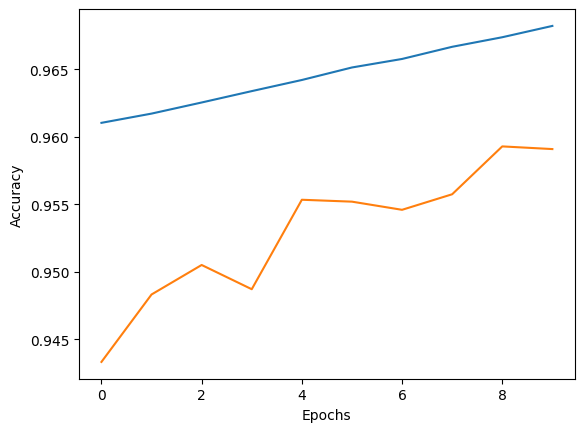

In [249]:
print(hist.history.keys())

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()